In [38]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict,Annotated
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
from pydantic import BaseModel,Field
import operator


In [39]:
load_dotenv()

True

In [40]:
model=ChatOpenAI(model='gpt-5.6-luna')

In [41]:
class EvaluationSchema(BaseModel):
    feedback: str=Field(description='Detailed Feedback for the essay')
    score: int=Field(description='Score out of 10',ge=0,le=10)

In [42]:
structured_model=model.with_structured_output(EvaluationSchema)

In [43]:
essay='''"""Europe in the Age of AI: The Regulatory Superpower

As the world rushes headlong into the era of artificial intelligence, the European Union finds itself playing a unique and complex role. While the United States and China dominate the race to build the largest foundation models and hardware ecosystems, Europe has positioned itself as the global conscience of the AI age. For Europe, the challenge is not simply about technological supremacy, but about ensuring that AI aligns with democratic values, human rights, and environmental sustainability.

Europe's strengths lie in its deep academic traditions and its commitment to ethical frameworks. The continent is home to world-class research hubs, producing some of the leading minds in machine learning. Furthermore, Europe has a distinct advantage in industrial and B2B AI, driven by its manufacturing powerhouses in Germany, France, and Scandinavia. However, Europe’s most defining characteristic in this era is its regulatory muscle. With the passage of the AI Act, the EU has created the world’s first comprehensive legal framework for artificial intelligence, categorizing systems by risk and demanding unprecedented transparency from tech companies.

The European vision for AI is heavily focused on public good and sustainability. There is a strong push toward "Green AI," ensuring that the massive energy consumption of data centers aligns with the continent's aggressive climate goals. In healthcare, European nations are leveraging AI to advance precision medicine and streamline public health systems, while fiercely protecting patient data. Additionally, significant investments are being made to develop open-source, multilingual AI models that preserve Europe's rich linguistic diversity and reduce reliance on Silicon Valley.

Despite these noble ambitions, Europe faces substantial hurdles. The continent suffers from a severe lack of hyperscale tech companies and domestic cloud infrastructure, leaving it heavily dependent on foreign technology. This "compute deficit" is compounded by a fragmented venture capital market, which often struggles to commercialize academic breakthroughs. Consequently, Europe frequently experiences a brain drain, as its brightest AI researchers are lured away by the massive salaries and computing resources offered by American and Chinese tech giants.

The central tension for Europe is whether its regulatory approach will foster "trustworthy AI" or stifle homegrown innovation. Critics argue that stringent compliance burdens will price European startups out of the market, relegating the continent to being a consumer of foreign AI rather than a creator. Proponents, however, believe that by setting global ethical standards—the "Brussels Effect"—Europe will ultimately attract users and enterprises that demand secure, unbiased, and privacy-respecting technologies.

To succeed, Europe must balance its protective instincts with aggressive investment in digital infrastructure and innovation. It needs to foster a unified digital single market that allows startups to scale across borders effortlessly, while also forging strategic alliances to secure supply chains for critical hardware like semiconductors.

In conclusion, Europe in the age of AI represents a profound geopolitical experiment. It is testing whether a society can successfully govern exponential technology without sacrificing economic competitiveness. If Europe succeeds, it will provide a desperately needed global blueprint for human-centric AI; if it fails, it risks becoming an over-regulated museum in a world driven by algorithmic innovation."""'''

In [44]:
prompt = f'Evaluate the language quality of the following essay and provide a feedback and assign a score out of 10 \n {essay}'
result=structured_model.invoke(prompt)


In [45]:
result

EvaluationSchema(feedback='The essay demonstrates a high level of language quality. It is coherent, well organized, and written in a confident, professional style. The introduction establishes the central argument effectively, while the body paragraphs develop Europe’s strengths, ambitions, obstacles, and strategic choices in a logical sequence. The conclusion returns to the main theme and ends with a memorable contrast between Europe as a “global blueprint” and an “over-regulated museum.” Word choice is generally precise and sophisticated, with effective terms such as “regulatory muscle,” “compute deficit,” “brain drain,” and “Brussels Effect.” Sentence structure is varied, and transitions such as “Furthermore,” “Despite these noble ambitions,” “Consequently,” and “In conclusion” help maintain cohesion.\n\nThe main weakness is that the prose occasionally becomes overly rhetorical or generalized. Phrases such as “playing a unique and complex role,” “global conscience of the AI age,” “d

In [46]:
result.feedback

'The essay demonstrates a high level of language quality. It is coherent, well organized, and written in a confident, professional style. The introduction establishes the central argument effectively, while the body paragraphs develop Europe’s strengths, ambitions, obstacles, and strategic choices in a logical sequence. The conclusion returns to the main theme and ends with a memorable contrast between Europe as a “global blueprint” and an “over-regulated museum.” Word choice is generally precise and sophisticated, with effective terms such as “regulatory muscle,” “compute deficit,” “brain drain,” and “Brussels Effect.” Sentence structure is varied, and transitions such as “Furthermore,” “Despite these noble ambitions,” “Consequently,” and “In conclusion” help maintain cohesion.\n\nThe main weakness is that the prose occasionally becomes overly rhetorical or generalized. Phrases such as “playing a unique and complex role,” “global conscience of the AI age,” “deep academic traditions,” 

In [47]:
result.score

9

In [48]:
class EssayState(TypedDict):
    essay: str
    language_feedback: str
    analysis_feedback: str
    clarity_feedback: str
    overall_feedback: str
    individual_scores: Annotated[list[int], operator.add]
    avg_score: float


In [49]:
def evaluate_language(state: EssayState):
    prompt = (
        "Evaluate the language quality of the following essay and provide feedback "
        "and assign a score out of 10\n"
        f"{state['essay']}"
    )
    output = structured_model.invoke(prompt)
    return {
        "language_feedback": output.feedback,
        "individual_scores": [output.score],
    }

In [50]:
def evaluate_analysis(state: EssayState):
    prompt = (
        "Evaluate the depth of analysis of the following essay and provide feedback "
        "and assign a score out of 10\n"
        f"{state['essay']}"
    )
    output = structured_model.invoke(prompt)
    return {
        "analysis_feedback": output.feedback,
        "individual_scores": [output.score],
    }

In [51]:
def evaluate_thought(state: EssayState):
    prompt = (
        "Evaluate the clarity of thought of the following essay and provide feedback "
        "and assign a score out of 10\n"
        f"{state['essay']}"
    )
    output = structured_model.invoke(prompt)
    return {
        "clarity_feedback": output.feedback,
        "individual_scores": [output.score],
    }

In [52]:
def final_evaluation(state: EssayState):
    prompt = (
        "Based on the following feedbacks create a summarized feedback\n"
        f"language feedback - {state['language_feedback']}\n"
        f"depth of analysis feedback - {state['analysis_feedback']}\n"
        f"clarity of thought feedback - {state['clarity_feedback']}"
    )
    overall_feedback = structured_model.invoke(prompt)

    scores = state.get("individual_scores", [])
    avg_score = sum(scores) / len(scores) if scores else 0

    return {
        "overall_feedback": overall_feedback.feedback,
        "avg_score": avg_score,
    }

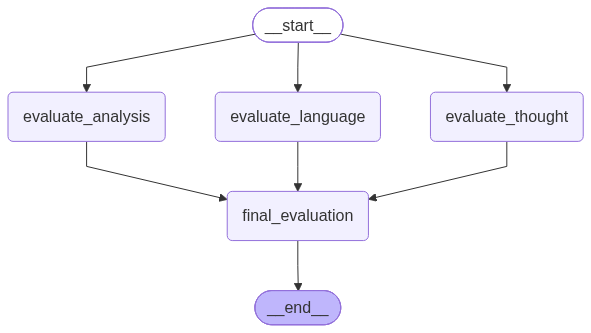

In [53]:
graph = StateGraph(EssayState)

graph.add_node("evaluate_analysis", evaluate_analysis)
graph.add_node("evaluate_language", evaluate_language)
graph.add_node("evaluate_thought", evaluate_thought)
graph.add_node("final_evaluation", final_evaluation)

graph.add_edge(START, "evaluate_analysis")
graph.add_edge(START, "evaluate_language")
graph.add_edge(START, "evaluate_thought")
graph.add_edge("evaluate_analysis", "final_evaluation")
graph.add_edge("evaluate_language", "final_evaluation")
graph.add_edge("evaluate_thought", "final_evaluation")
graph.add_edge("final_evaluation", END)

workflow = graph.compile()
workflow

In [54]:
initial_state = {
    "essay": essay,
}
result = workflow.invoke(initial_state)
result

{'essay': '"""Europe in the Age of AI: The Regulatory Superpower\n\nAs the world rushes headlong into the era of artificial intelligence, the European Union finds itself playing a unique and complex role. While the United States and China dominate the race to build the largest foundation models and hardware ecosystems, Europe has positioned itself as the global conscience of the AI age. For Europe, the challenge is not simply about technological supremacy, but about ensuring that AI aligns with democratic values, human rights, and environmental sustainability.\n\nEurope\'s strengths lie in its deep academic traditions and its commitment to ethical frameworks. The continent is home to world-class research hubs, producing some of the leading minds in machine learning. Furthermore, Europe has a distinct advantage in industrial and B2B AI, driven by its manufacturing powerhouses in Germany, France, and Scandinavia. However, Europe’s most defining characteristic in this era is its regulator